In [12]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_stat_map

%load_ext autoreload
%autoreload 2
from review_results_utils import get_p_t_maps, process_pairwise_maps

from survey_medley_code.config_loader import load_config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Pairwise T-test Conjunction Results

The code calculates all possible conjunctions between the 20 maps (positive and negative significance for each of the 10 paired comparisons). For conjunction maps with at least 1 cluster with >400 voxels, the conjunction map is displayed on top of the f-test significance maps.  All of the maps are binary (significant or not significant). The maps are coded:
  - **Yellow** = F-test only  
  - **Blue** = Conjunction only  
  - **Green** = Both F-test and conjunction

The first set of maps corresponds to the tests using the questionnaire brain-behavior slopes that are not adjusted for question character count and the second set of maps use the adjusted brain-behavior slopes.

In [4]:
cfg = load_config()
mask_path = (
    cfg.output_root / 'assess_subject_bold_dropout/group_mask_intersection_30pct.nii.gz'
)

outdir = cfg.output_root / 'within_subject_brain_behavior_by_questionnaire'
omnibus_pmap_file = cfg.output_root / 'questionnaire_brain_behavior_slope_ftest/output_glm_ftest/glm_tfce_corrp_fstat1.nii.gz'
omnibus_pmap_file_adjusted = cfg.output_root / 'questionnaire_brain_behavior_slope_ftest/adjusted_output_glm_ftest/glm_tfce_corrp_fstat1.nii.gz'
paired_outdir = outdir / 'all_paired_t_tests'
paired_outdir_adjusted = outdir / 'all_adjusted_paired_t_tests'

In [11]:
question_pmaps_unadjusted, question_tmaps_unadjusted = get_p_t_maps(paired_outdir)
question_pmaps_adjusted, question_tmaps_adjusted = get_p_t_maps(paired_outdir_adjusted)

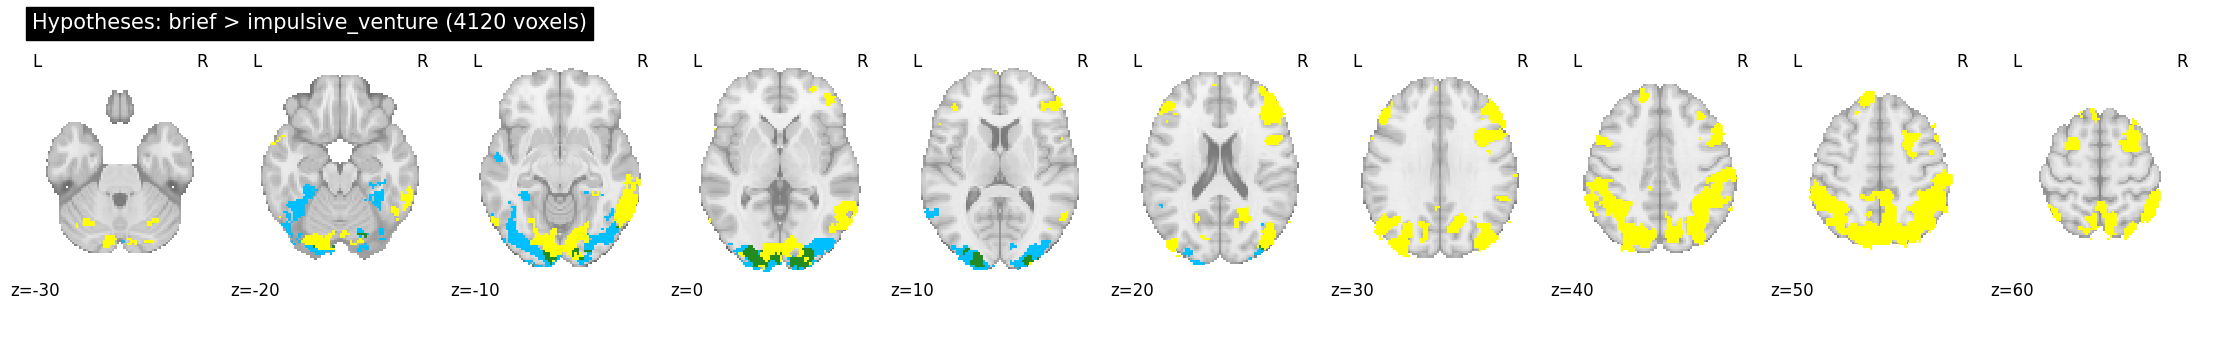

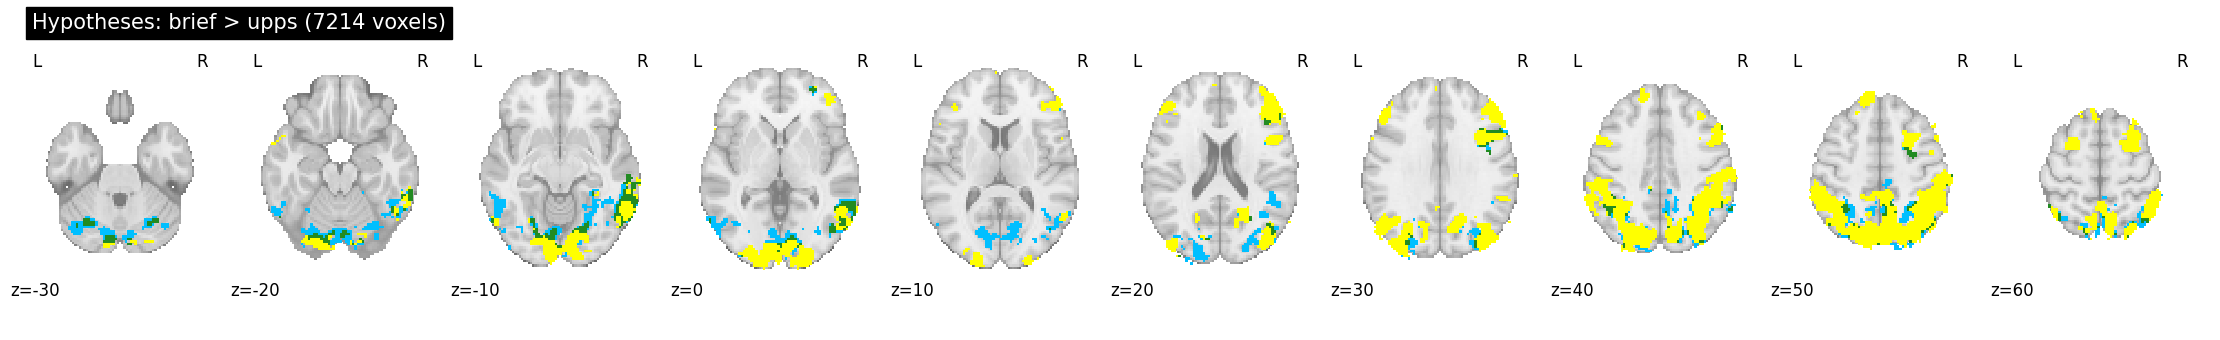

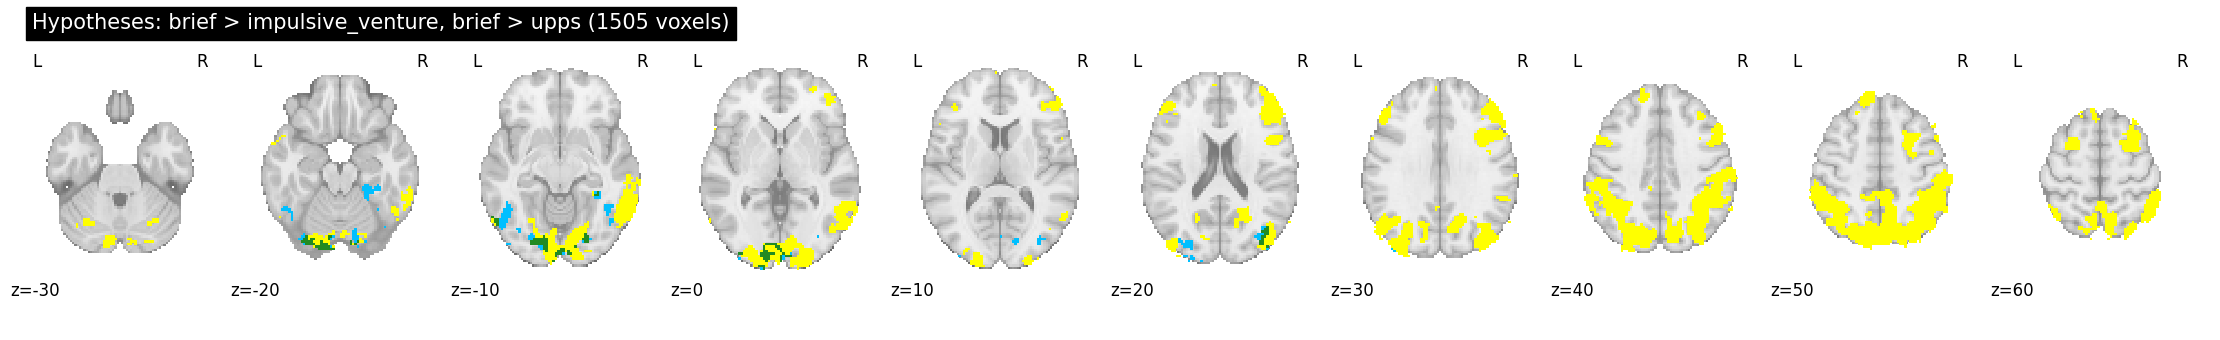

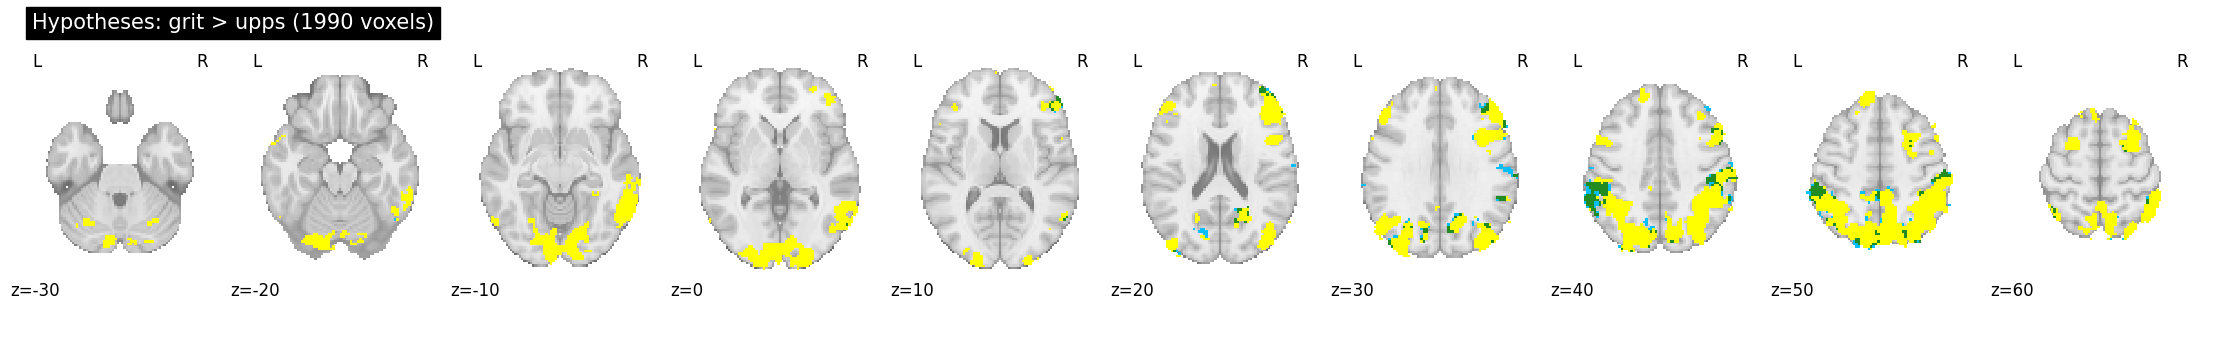

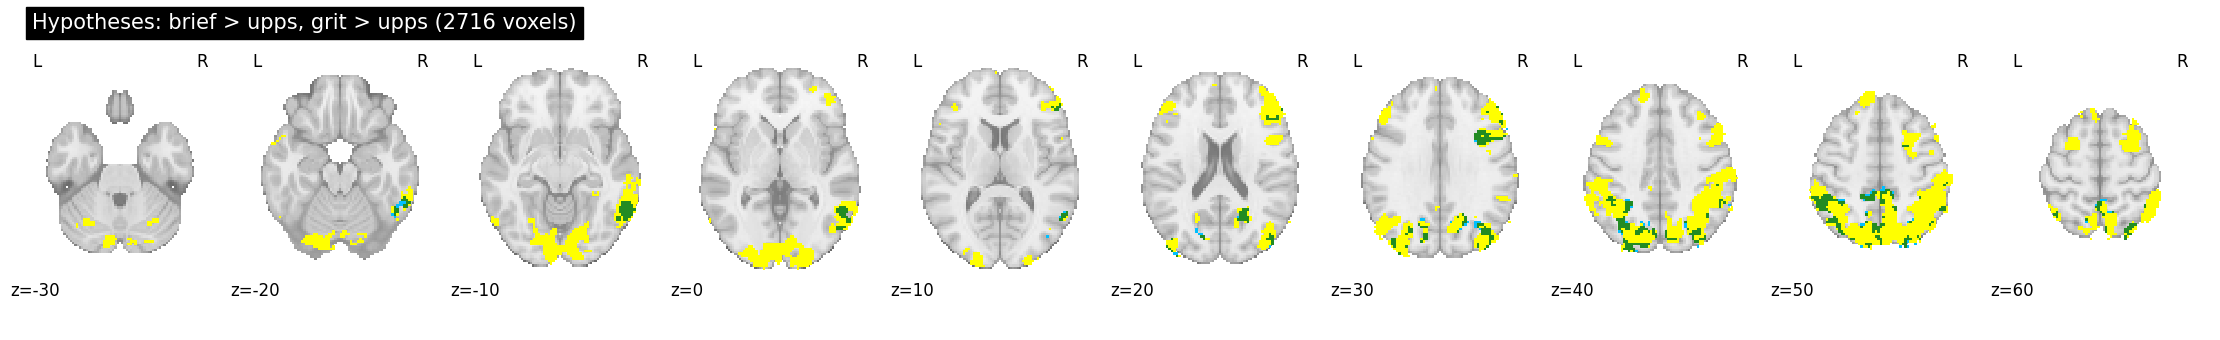

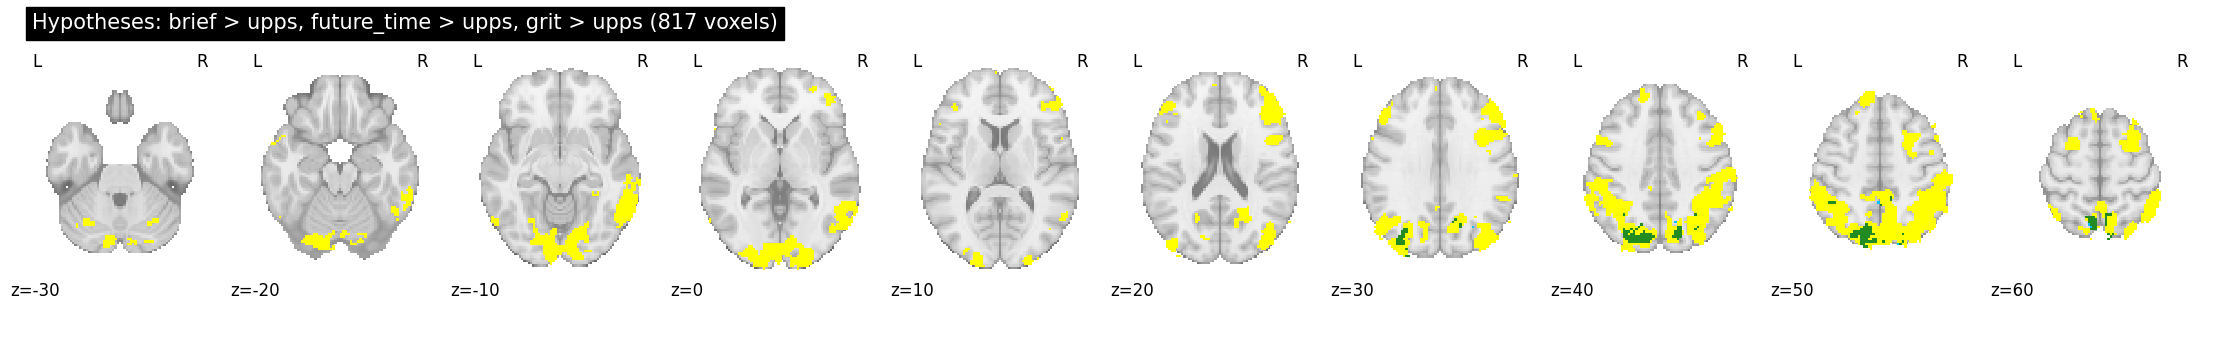

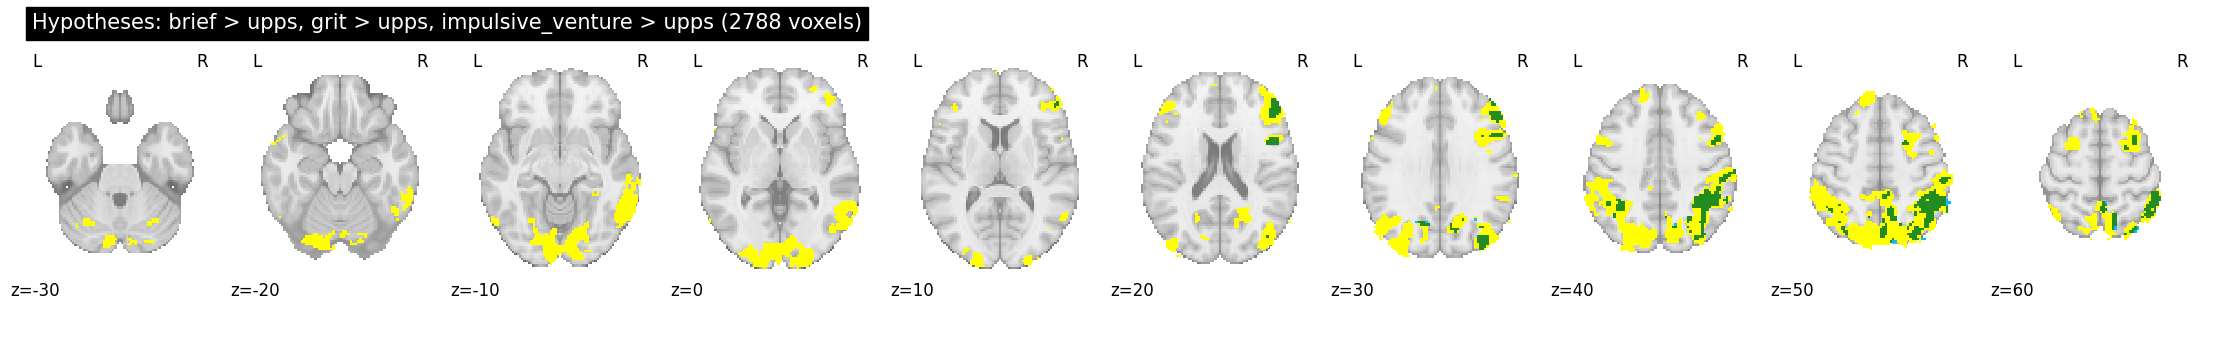

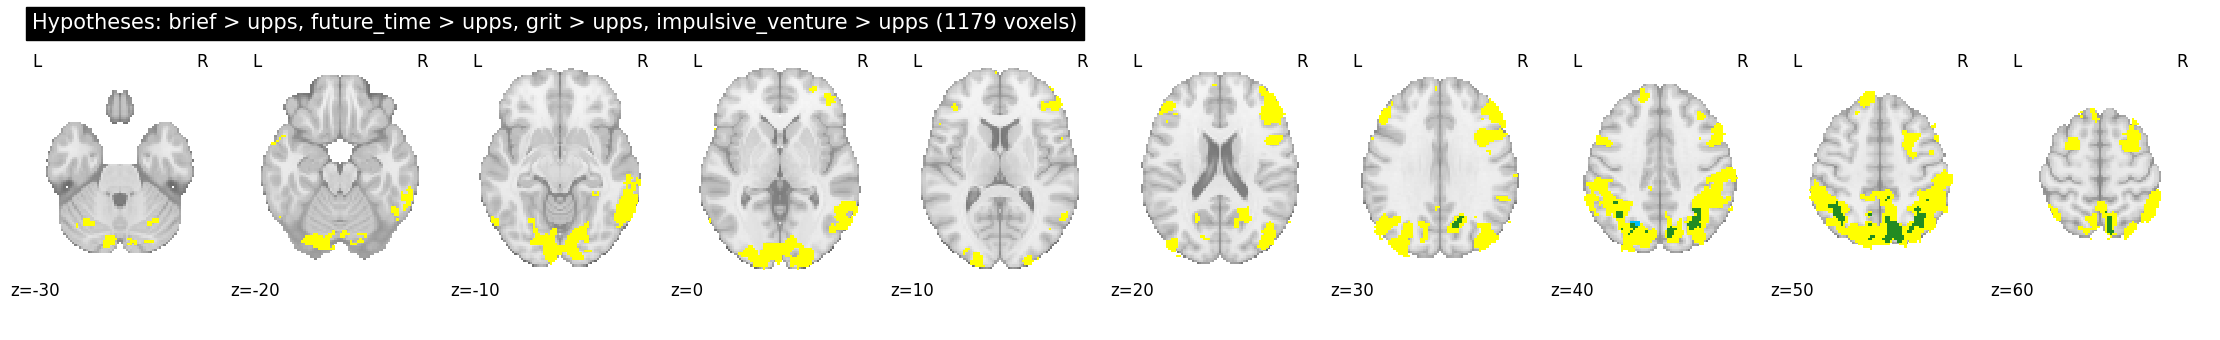

In [13]:
z_slices = list(range(-30, 61, 10))

process_pairwise_maps(
    question_tmaps_unadjusted,
    question_pmaps_unadjusted,
    omnibus_pmap_file,
    mask_path,
    z_slices,
    t_threshold=0.05,
    omnibus_f_threshold=0.05,
    min_cluster_vox=400,
)

### Repeat with Adjusted data
The adjustment is for the number of characters within each question.

  - **Yellow** = F-test only  
  - **Blue** = Conjunction only  
  - **Green** = Both F-test and conjunction

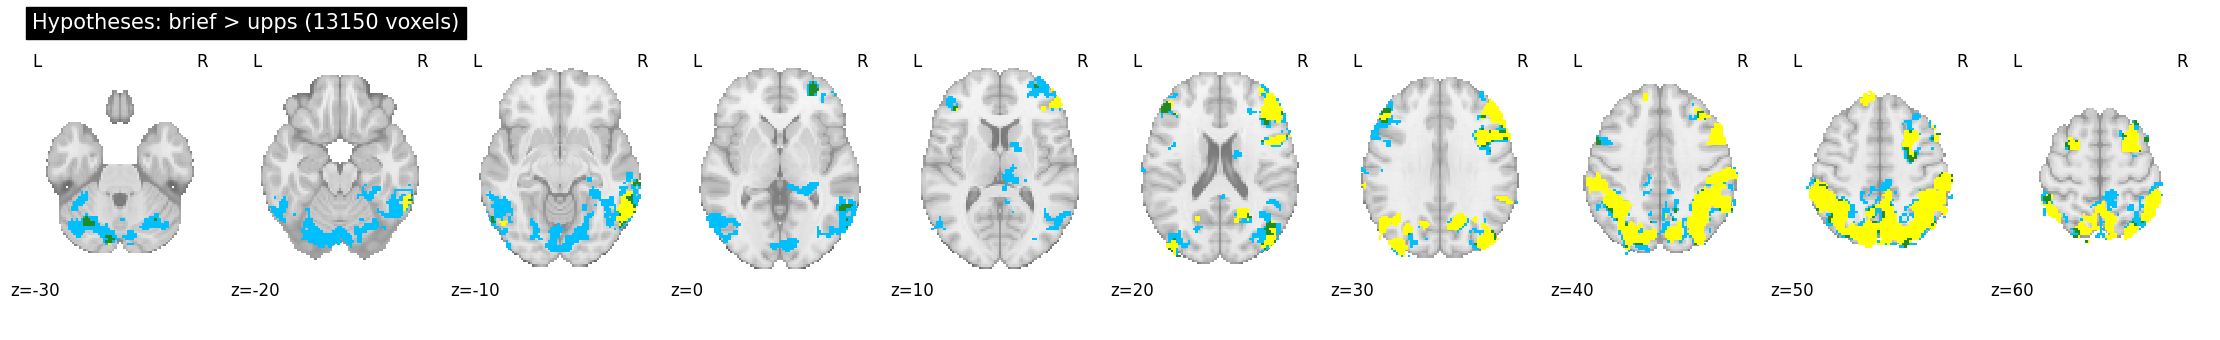

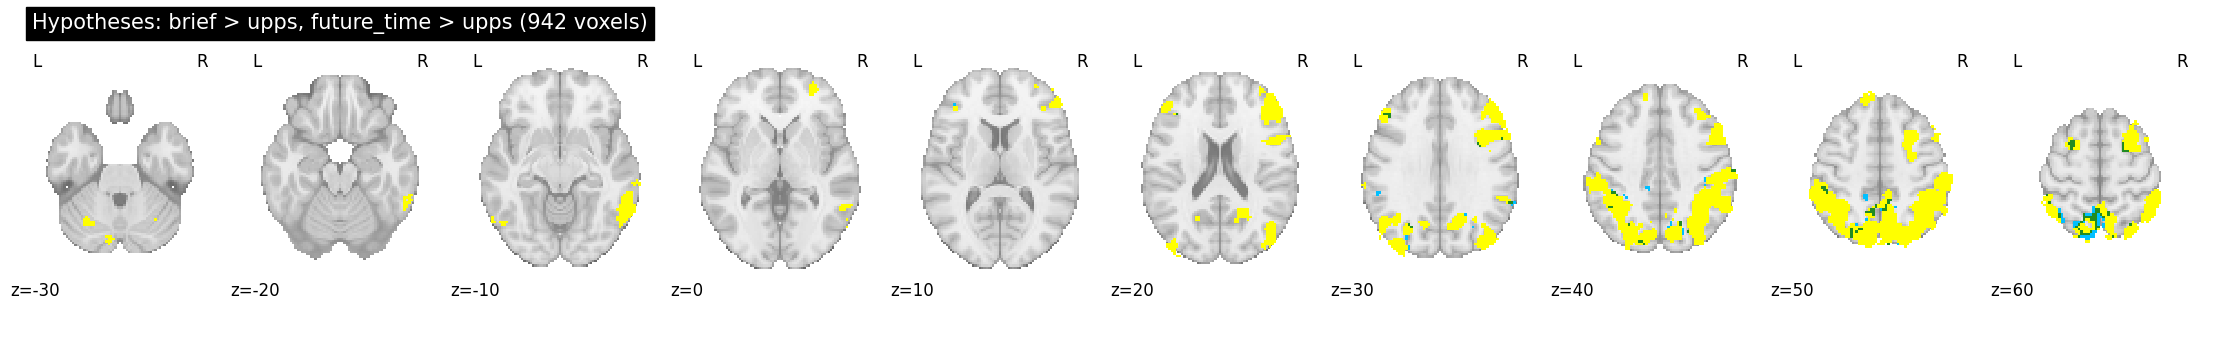

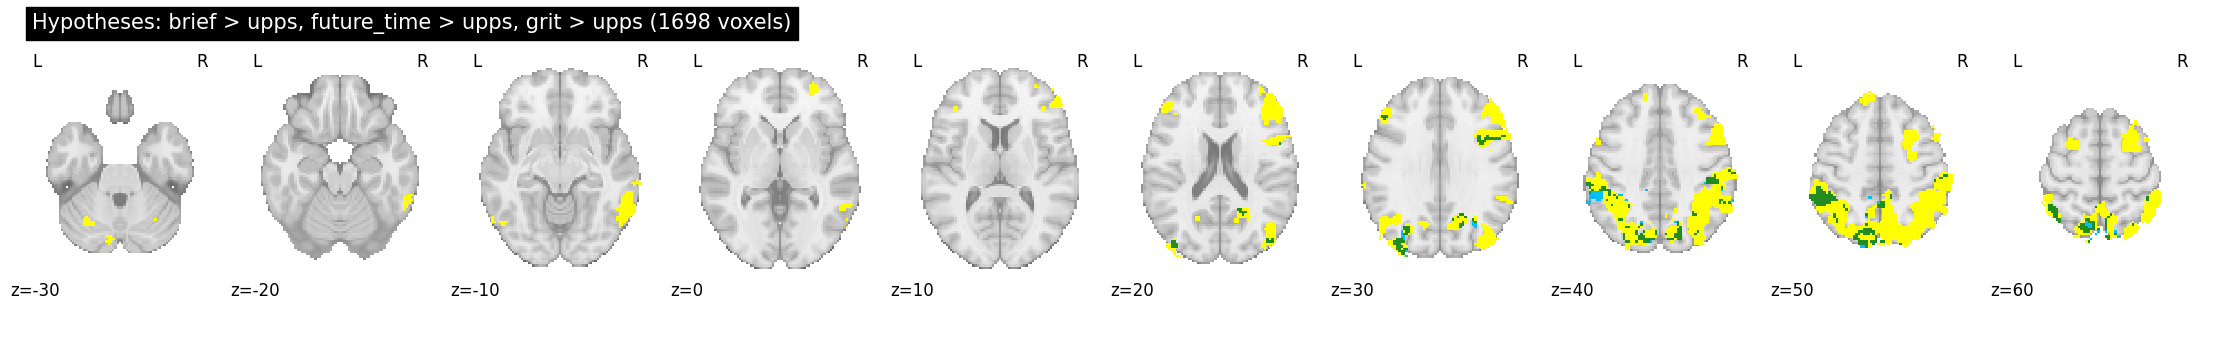

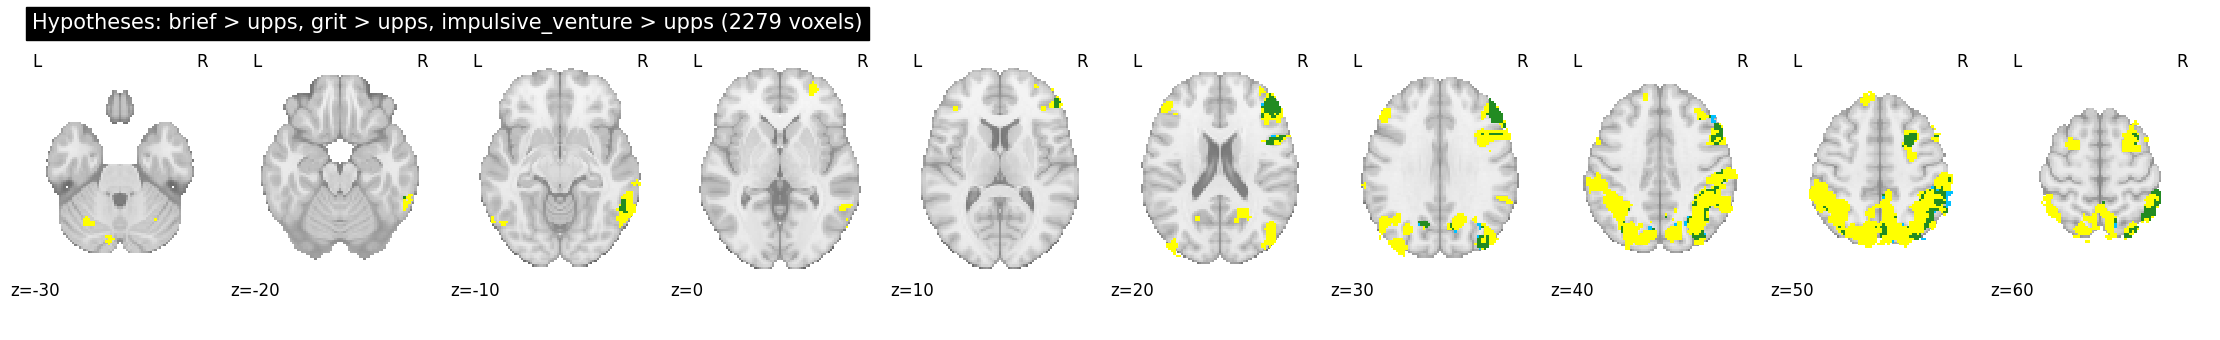

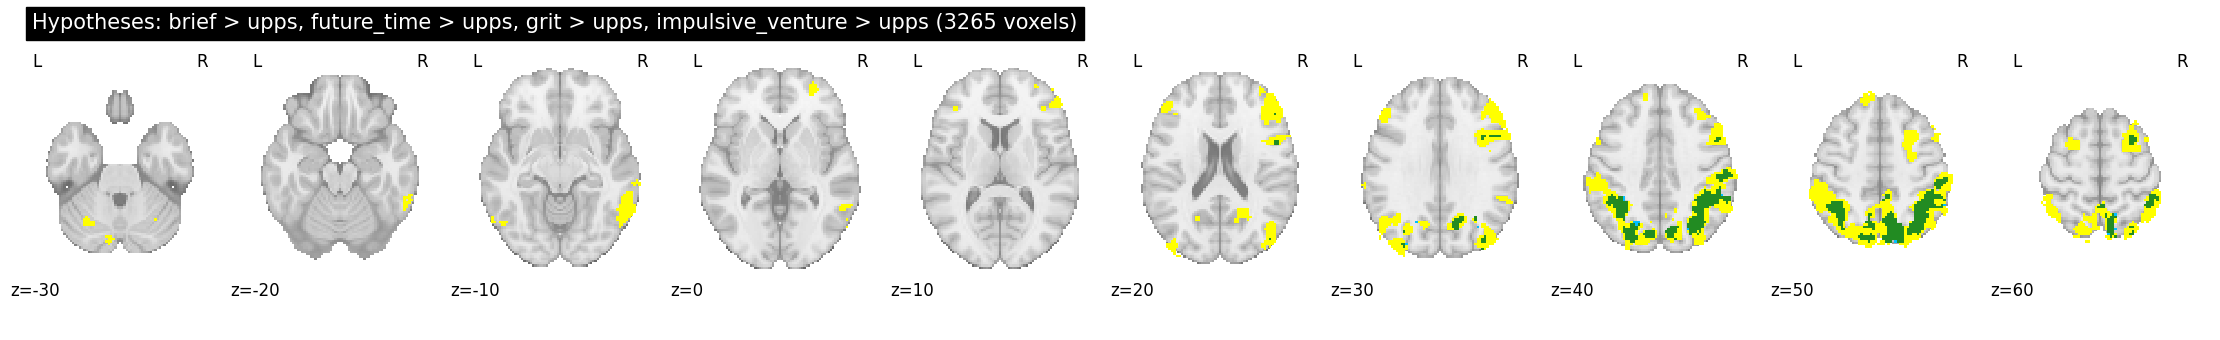

In [15]:
process_pairwise_maps(
    question_tmaps_adjusted,
    question_pmaps_adjusted,
    omnibus_pmap_file_adjusted,
    mask_path,
    z_slices,
    t_threshold=0.05,
    omnibus_f_threshold=0.05,
    min_cluster_vox=400,
)